In [50]:
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------
# importing required libraries
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import warnings
#--------------------------------------------------------------------------------------------------------------------------
# setting plot style and display options
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 100)
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------
# setting location of wine.json file for analysis
file = '../data/raw/wine.json'
#--------------------------------------------------------------------------------------------------------------------------
# Reading Wine file
with open(file, "r") as rfile:
    wineData = json.load(rfile) # Decoding and reading file data
#--------------------------------------------------------------------------------------------------------------------------
# Converting data into python panda dataframe
wine_data = pd.DataFrame(wineData)
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------

In [51]:
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------
# Converting types
wine_data["price"] = pd.to_numeric(wine_data["price"], errors="coerce")
wine_data["points"] = pd.to_numeric(wine_data["points"], errors="coerce")
#--------------------------------------------------------------------------------------------------------------------------
# Counting missing price/points
missing_mask = wine_data["price"].isna() | wine_data["points"].isna()
n_missing = missing_mask.sum()

print(f"Invalid price/points rows: {n_missing}")

#--------------------------------------------------------------------------------------------------------------------------
# print(f"Total rows before cleaning: {len(wine_data)}")
# Drop rows with missing price/points if wish to straigt away remove missing values raws
# wine_data = wine_data[~missing_mask].copy()
# print(f"Total rows after cleaning: {len(wine_data)}")
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------

Invalid price/points rows: 8996


There are 8996 rows with missing price or points.
Hence, dropping all of these rows will lead to substantial information loss and 
skewing analysis especially if missing values are not random.

Median imputation by category is robust, handles outliers, and provides realistic estimates for missing price 
and points based on what is typical for each wine variety (or country-variety pair).
We will be filling the missing values with country-variety pair.

In [ ]:
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------
warnings.filterwarnings("ignore", category=RuntimeWarning)
#--------------------------------------------------------------------------------------------------------------------------
# Filling missing price/points with median values by country-variety pair
# Price
wine_data["price"] = wine_data.groupby(["country", "variety"])["price"].transform(
    lambda x: x.fillna((x.median()))
    )
# Points
wine_data["points"] = wine_data.groupby(["country", "variety"])["points"].transform(
     lambda x: x.fillna(x.median())
     )

# Again Counting missing price/points
missing_mask = wine_data["price"].isna() | wine_data["points"].isna()
n_missing = missing_mask.sum()

print(f"Invalid price/points rows: {n_missing}")
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------

Invalid price/points rows: 91


Now, there are only 91 rows with missing price/points that did not fall under country-variety pair.
We will now drop those rows from dataset

In [ ]:
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------
print(f"Total rows before cleaning: {len(wine_data)}")
# Dropping rows with missing price/points
wine_data = wine_data[~missing_mask].copy()
print(f"Total rows after cleaning: {len(wine_data)}")
#--------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------

Total rows before cleaning: 129971
Total rows after cleaning: 129880


# Part 1: numeric anaysis

## 1.1 Explore the data distribution for each column.

In [56]:
#--------------------------------------------------------------------------------------------------------------------------
# Dataset Overview
print("Overview of the Dataset: ")
wine_data.info()
#--------------------------------------------------------------------------------------------------------------------------
wine_data[["points", "price"]].describe()

Overview of the Dataset: 
<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   points                 129880 non-null  float64
 1   title                  129880 non-null  object 
 2   description            129880 non-null  object 
 3   taster_name            103639 non-null  object 
 4   taster_twitter_handle  98673 non-null   object 
 5   price                  129880 non-null  float64
 6   designation            92432 non-null   object 
 7   variety                129880 non-null  object 
 8   region_1               108714 non-null  object 
 9   region_2               50511 non-null   object 
 10  province               129880 non-null  object 
 11  country                129880 non-null  object 
 12  winery                 129880 non-null  object 
dtypes: float64(2), object(11)
memory usage: 13.9+ MB


,points,price
count,129880.000000,129880.000000
mean,88.447213,34.911399
std,3.040056,39.780544
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


max price is:  3300.0


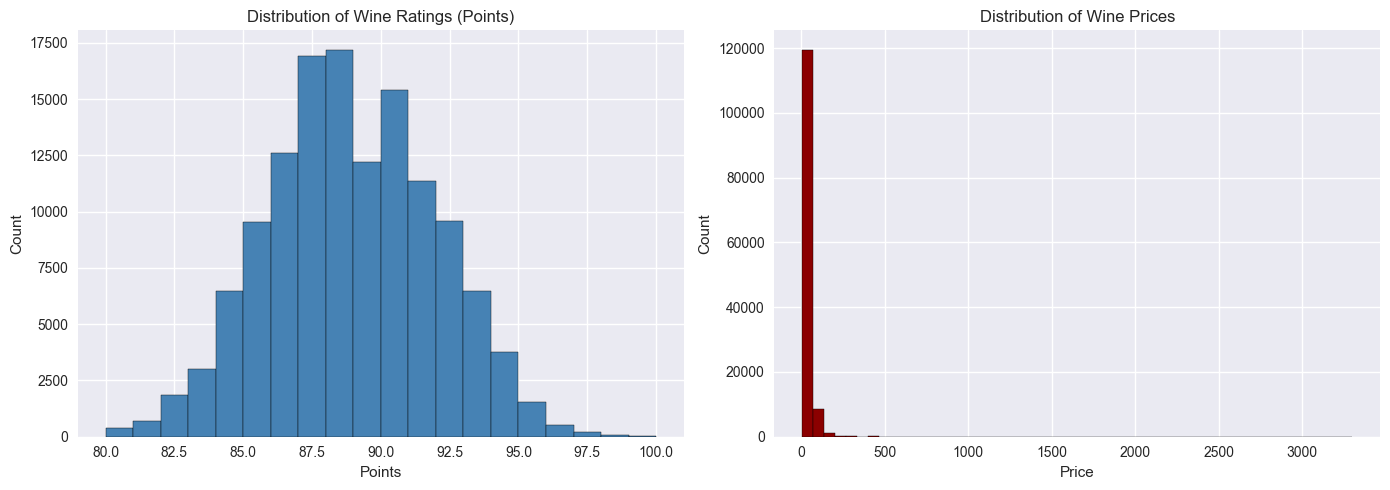

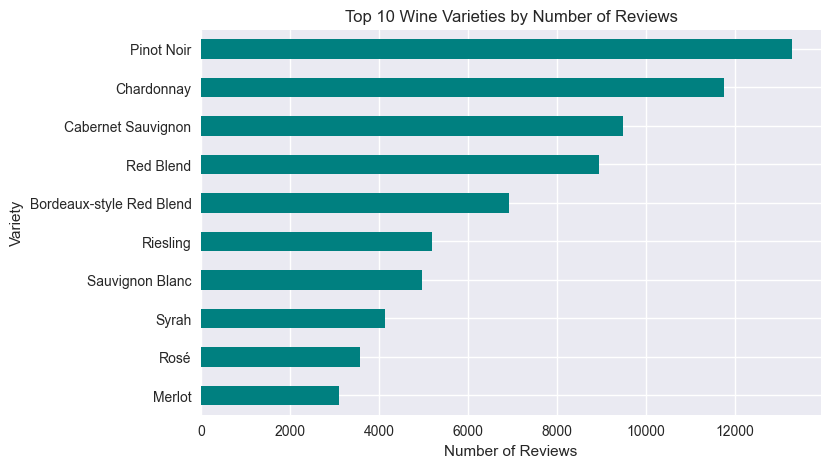

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(wine_data["points"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of Wine Ratings (Points)")
axes[0].set_xlabel("Points")
axes[0].set_ylabel("Count")

axes[1].hist(wine_data["price"], bins=50, color="darkred", edgecolor="black")
axes[1].set_xlim(0, 500)  # Limiting x-axis for better visualization
axes[1].set_title("Distribution of Wine Prices")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


top_varieties = wine_data["variety"].value_counts().head(10)
top_varieties

top_varieties.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Wine Varieties by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Variety")
plt.show()

## 1.3 Find varieties of wine having the average price less than 20, with the average pointsat least 90

In [ ]:
#--------------------------------------------------------------------------------------------------------------------------
print("Wine varieties with average price less than 20 and average points at least 90 are as follows: ")
# interating by each wine variety
for variet in list(wData["variety"].unique()):    
    data_check = wData[(wData.variety == variet)] # subseting data by variety
    if (data_check.price.mean() < 20 and pd.to_numeric(data_check.points).mean() >= 90): # Applying given filters or conditions
        print(variet) # printing the wine variety that meets the given conditions
#--------------------------------------------------------------------------------------------------------------------------

## 1.4 Build statistic table 

In [9]:
#--------------------------------------------------------------------------------------------------------------------------
# Defining DataFrame as per requirement with given 4 columns
statisticByStateData = pd.DataFrame(columns=["Country", "Variety", "AvgPoint", "AvgPrice"])
#--------------------------------------------------------------------------------------------------------------------------
# Iterating through each country
for cntry in list(wData['country'].unique()):
    fData = wData[(wData.country == cntry)] # subseting data by country
    if not(fData["variety"].empty): # checking if data cell is empty or not
        wine_name = fData["variety"].value_counts().idxmax() # getting variety name
        # adding row to dataframe if conditon is true
        statisticByStateData = statisticByStateData.append({"Country": cntry, "Variety": wine_name, 
                                                            "AvgPoint": round(pd.to_numeric(fData.points).mean(),2),
                                                            "AvgPrice": round(fData.price.mean(),2)}, ignore_index=True)

#print(statisticByStateData)
#--------------------------------------------------------------------------------------------------------------------------

In [10]:
# save your table to 'statisticByState.csv'
statisticByStateData.to_csv('statisticByState.csv', 
            encoding='utf-8', 
            index=False, 
            header=True)

## 1.5 Recommendations


Based on the analysis, which country/countries would you recommend *HOTEL TULIP* to source wine from? Pleas state your reasons.

---

Your Answer: Hotel TULIP should source wine from India, Bulgaria and China. Reasons are as follow.

- There are 42 countries in file hence consider top 5% to recommend which equal to 2-3 countries to recommend
- Average of AvgPrice is around 26.6 and Average of AvgPoint is around 87.7
- Hence after applying filters in generated CSV file top 3 countries with highest points and least price are
- India, Bulgaria and China
- Hence, this denots that compared to cheaper price these contries are good at wine making based on Points received
---
